<a href="https://colab.research.google.com/github/marklinista-HO/challenge2-data-science-LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción de datos

In [1]:
#Importando la biblioteca Pandas
import pandas as pd
#Importando el módulo JSON
import requests
import json

In [2]:
#  Este parámetro de  Pandas es para que se puedan ver TODAS las columnas
pd.set_option('display.max_columns',None)

In [3]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

Cargar datos al DF:  datos_telecom

In [4]:
#
datos_archivo = requests.get(url)

In [5]:
resultado = json.loads(datos_archivo.text)

In [6]:
datos_telecom = pd.DataFrame(resultado)
datos_telecom.head(1)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."


In [7]:
datos_telecom.shape

(7267, 6)

In [8]:
#  Normalizando el DF:
datos_telecom_norm = pd.json_normalize(resultado)

##DF  ya  normalizado

In [9]:
datos_telecom_norm.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [10]:
datos_telecom_norm.shape

(7267, 21)

In [11]:
type(datos_telecom_norm)

pandas.core.frame.DataFrame

In [12]:
#
datos_telecom_norm.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

##Renombrando columnas

El nombre de las columnas quedó sin puntos y de una sóla palabra

In [13]:
#  cambiar nombres de las columnas:  quitar   customer.
datos_telecom_norm.rename(columns={'customer.gender':'gender', 'customer.SeniorCitizen':'SeniorCitizen',
       'customer.Partner':'Partner', 'customer.Dependents':'Dependents',
       'customer.tenure':'tenure'}, inplace=True)

#  cambiar nombres de las columnas:  quitar   phone.
datos_telecom_norm.rename(columns={'phone.PhoneService':'PhoneService', 'phone.MultipleLines':'MultipleLines'}, inplace=True)

#  cambiar nombres de las columnas:  quitar   internet.
datos_telecom_norm.rename(columns={'internet.InternetService':'InternetService',
       'internet.OnlineSecurity':'OnlineSecurity', 'internet.OnlineBackup':'OnlineBackup',
       'internet.DeviceProtection':'DeviceProtection', 'internet.TechSupport':'TechSupport',
       'internet.StreamingTV':'StreamingTV', 'internet.StreamingMovies':'StreamingMovies'}, inplace=True)

#  cambiar nombres de las columnas:  quitar   account.Contract.
datos_telecom_norm.rename(columns={'account.Contract':'Contract',
       'account.PaperlessBilling':'PaperlessBilling', 'account.PaymentMethod':'PaymentMethod',
       'account.Charges.Monthly':'Monthly', 'account.Charges.Total':'Total'}, inplace=True)

In [14]:
#  Revisando nombre de columnas:
datos_telecom_norm.head(2)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4


#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Monthly`: total de todos los servicios del cliente por mes
- `Total`: total gastado por el cliente


#🔧 Transformación

In [15]:
#  Verificando nulls y tipo de datos:
datos_telecom_norm.info()
#  NO hay nulos, pero NO todos deben ser   object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [16]:
datos_telecom_norm.head(3)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


##01 Cambiando la columna  'Total' a  float

In [17]:
#  Revisando, parece todo bien, pero nos dio error de datos con  ' ':
datos_telecom_norm['Total'].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [18]:
#  Contando los registros con valor = ' ':
datos_telecom_norm.query("Total == ' '")[['Monthly']].count(numeric_only=True)

,0
Monthly,11


In [19]:
#  Revisando otros datos relacionados con  'Total'
datos_telecom_norm.query("tenure ==  0")[['Churn','tenure','Monthly','Total']]
#  Como  'tenure'  es 0 meses, se puede poner 0 en 'Total'

,Churn,tenure,Monthly,Total
975,No,0,56.05,
1775,No,0,20.00,
1955,No,0,61.90,
2075,No,0,19.70,
2232,No,0,20.25,
2308,No,0,25.35,
2930,No,0,73.35,
3134,No,0,25.75,
3203,No,0,52.55,
4169,No,0,80.85,


In [20]:
#  reemplazando el  ' ' por un 0 que daba error
datos_telecom_norm['Total'] = datos_telecom_norm['Total'].replace(' ','0')

In [21]:
#  haciendo la conversión a float :
#datos_telecom_norm.astype({'Total':'float64'})
datos_telecom_norm = datos_telecom_norm.astype({'Total':'float64'})

In [22]:
#  Comprobando conversión;
datos_telecom_norm.dtypes
datos_telecom_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


##02 Verificando valores únicos en cols.

In [23]:
for column in datos_telecom_norm.columns:
  #print(column)
  print(datos_telecom_norm[column].nunique(),' ', column)
  print(datos_telecom_norm[column].unique())
  #{df[col].nunique()}'")

7267   customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
3   Churn
['No' 'Yes' '']
2   gender
['Female' 'Male']
2   SeniorCitizen
[0 1]
2   Partner
['Yes' 'No']
2   Dependents
['Yes' 'No']
73   tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
2   PhoneService
['Yes' 'No']
3   MultipleLines
['No' 'Yes' 'No phone service']
3   InternetService
['DSL' 'Fiber optic' 'No']
3   OnlineSecurity
['No' 'Yes' 'No internet service']
3   OnlineBackup
['Yes' 'No' 'No internet service']
3   DeviceProtection
['No' 'Yes' 'No internet service']
3   TechSupport
['Yes' 'No' 'No internet service']
3   StreamingTV
['Yes' 'No' 'No internet service']
3   StreamingMovies
['No' 'Yes' 'No internet service']
3   Contract
['One year' 'Month-to-month' 'Two year']
2   PaperlessBilling
['Yes' '

##03 Eliminar registros con vacío en churn

In [24]:
#  Revisando valores en  Churn
#  datos_telecom_norm['Churn'].unique()
datos_telecom_norm.Churn.unique()

array(['No', 'Yes', ''], dtype=object)

In [25]:
#  Queremos remover registros con  Churn == '':
#  contando los registros a eliminar:
datos_telecom_norm.query("Churn == ''")[['Total']].count(numeric_only=True)

,0
Total,224


In [26]:
#  Queremos remover registros con  Churn == '':
#  para encontrar registros con este valor:
datos_telecom_norm.query("Churn == ''")

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,Yes,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.30
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.10
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,Yes,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.20
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,Yes,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,No,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.20
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,Yes,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.90


In [27]:
#  Para accesarlos, encontramos sus indices:
datos_telecom_norm.query("Churn == ''").index

Index([  30,   75,   96,   98,  175,  219,  312,  351,  368,  374,
       ...
       7058, 7061, 7062, 7143, 7155, 7158, 7180, 7211, 7239, 7247],
      dtype='int64', length=224)

In [28]:
#  hacemos un DF para remover , que sería nuestro filtro
df_remover = datos_telecom_norm.query("Churn == ''").index

In [29]:
#  ahora ya podemos hacer el drop de los registros
#  axis=0  le indica que son las filas
#  inplace=True    lo ejecuta sin necesidad de asignarlo a una variable
datos_telecom_norm.drop(df_remover,axis=0,inplace=True)

In [30]:
#  Ahora deben de hacer 7267 - 224 =  7043  registros:
datos_telecom_norm.shape

(7043, 21)

In [31]:
#  ahora volvemos a hacer la consulta y  debe  estar vacía la lista:
print(datos_telecom_norm.query("Churn == ''")[['Total']].count(numeric_only=True))
datos_telecom_norm.query("Churn == ''")

Total    0
dtype: int64


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total


In [32]:
#  Reseteando los índices para que no haya desfasados
datos_telecom_norm.reset_index(drop=True, inplace=True)
datos_telecom_norm

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7039,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7040,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7041,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


##04 Revisando duplicados

In [33]:
#         .duplicated
#  Revisando si hay valores duplicados:
datos_telecom_norm.duplicated().sum()
#
print('Duplicados = ',datos_telecom_norm.duplicated().sum())
#  NO  hay  duplicados

Duplicados =  0


##05 Verificando valores nulos

In [34]:
# datos_telecom_norm.isnull()
# datos_telecom_norm.isnull().sum()
print('NULOS: ',datos_telecom_norm.isnull().sum().sum())
#  NO  HAY

NULOS:  0


##06 Valores vacíos o en blanco

In [35]:
#
datos_telecom_norm.apply(lambda x: x.astype(str).str.strip() == ' ').sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [36]:
#  Revisando si hay datos en blanco:
for column in datos_telecom_norm.columns[:20]:
  print(column)
  print(datos_telecom_norm.query(column + " == ' '")[['Total']].count(numeric_only=True))


print("-*-*-*-*-*-*-*-*-*- OTRA FORMA DE REVISAR -*-*-*-*-*-*-*-*-*-*-*-")

for column in datos_telecom_norm.columns[:20]:
  print(column)
  print(list(datos_telecom_norm.query(column + " == ''")[['Total']].count(numeric_only=True)))



customerID
Total    0
dtype: int64
Churn
Total    0
dtype: int64
gender
Total    0
dtype: int64
SeniorCitizen
Total    0
dtype: int64
Partner
Total    0
dtype: int64
Dependents
Total    0
dtype: int64
tenure
Total    0
dtype: int64
PhoneService
Total    0
dtype: int64
MultipleLines
Total    0
dtype: int64
InternetService
Total    0
dtype: int64
OnlineSecurity
Total    0
dtype: int64
OnlineBackup
Total    0
dtype: int64
DeviceProtection
Total    0
dtype: int64
TechSupport
Total    0
dtype: int64
StreamingTV
Total    0
dtype: int64
StreamingMovies
Total    0
dtype: int64
Contract
Total    0
dtype: int64
PaperlessBilling
Total    0
dtype: int64
PaymentMethod
Total    0
dtype: int64
Monthly
Total    0
dtype: int64
-*-*-*-*-*-*-*-*-*- OTRA FORMA DE REVISAR -*-*-*-*-*-*-*-*-*-*-*-
customerID
[0]
Churn
[0]
gender
[0]
SeniorCitizen
[0]
Partner
[0]
Dependents
[0]
tenure
[0]
PhoneService
[0]
MultipleLines
[0]
InternetService
[0]
OnlineSecurity
[0]
OnlineBackup
[0]
DeviceProtection
[0]
TechSuppor

Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

##07 Crear Col. Daily

In [37]:
#  Creando la columna  'Daily'   El costo de los servicios del cliente por día
datos_telecom_norm['Daily'] = datos_telecom_norm['Monthly'] / 30

In [38]:
#   Revisando columna agregada:
datos_telecom_norm.head(3)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Daily
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333


In [39]:
#  Revisando nuevamente los datos:
datos_telecom_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


##08 Nuevamente Verificando valores únicos en cols.

In [40]:
#  Verificando valores únicos en las columnas:
for column in datos_telecom_norm.columns:
  #print(column)
  print(datos_telecom_norm[column].nunique(),' ', column)
  print(datos_telecom_norm[column].unique())
  print('---------------------------------')
  #{df[col].nunique()}'")

7043   customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
---------------------------------
2   Churn
['No' 'Yes']
---------------------------------
2   gender
['Female' 'Male']
---------------------------------
2   SeniorCitizen
[0 1]
---------------------------------
2   Partner
['Yes' 'No']
---------------------------------
2   Dependents
['Yes' 'No']
---------------------------------
73   tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
---------------------------------
2   PhoneService
['Yes' 'No']
---------------------------------
3   MultipleLines
['No' 'Yes' 'No phone service']
---------------------------------
3   InternetService
['DSL' 'Fiber optic' 'No']
---------------------------------
3   OnlineSecurity
['No' 'Yes' 'No internet service']
-----------

#📊 Carga y análisis

##1.Analisis Descriptivo

In [41]:
datos_telecom_norm.describe()

,SeniorCitizen,tenure,Monthly,Total,Daily
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,2.158723
std,0.368612,24.559481,30.090047,2266.794470,1.003002
min,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,9.000000,35.500000,398.550000,1.183333
50%,0.000000,29.000000,70.350000,1394.550000,2.345000
75%,0.000000,55.000000,89.850000,3786.600000,2.995000
max,1.000000,72.000000,118.750000,8684.800000,3.958333


##2.Distribución de la Evasión

###% de abandono

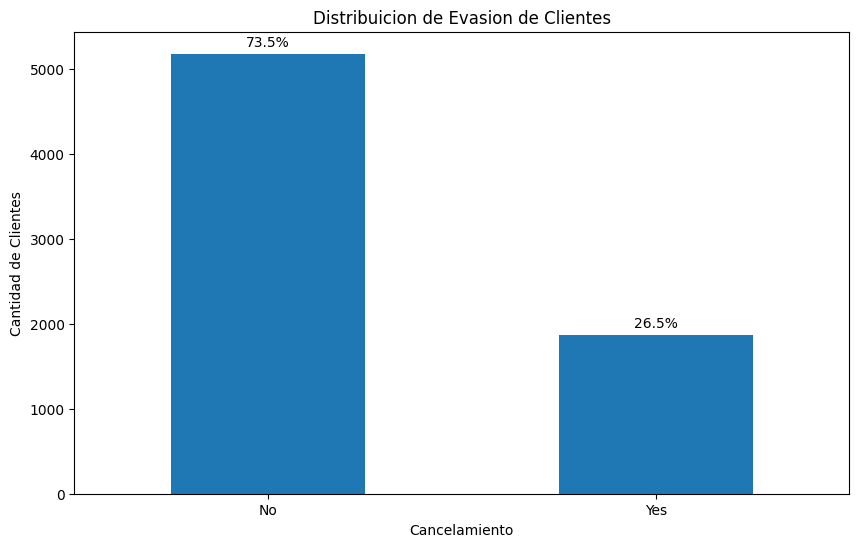

In [42]:
import matplotlib.pyplot as plt
#
plt.figure(figsize=(10, 6))
churn_counts =datos_telecom_norm['Churn'].value_counts()
churn_percentages = (churn_counts / len(datos_telecom_norm)) * 100
#
ax = churn_counts.plot(kind='bar')
plt.title('Distribuicion de Evasion de Clientes')
plt.xlabel('Cancelamiento')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
#
for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')
#
plt.show()

####ALERTA 1:   % de abandono

Arriba del 25% de abandono debe causar preocupación!


---




###Distrib. entre género

In [43]:
import plotly.express as px

In [44]:
px.histogram(datos_telecom_norm, x = 'gender', text_auto = True, color = 'Churn', barmode = 'group')

####OBSERV 1:  Género NO está afectando

En las cancelaciones, NO hay tendencia hacia algún género.  El género NO está afectando directamente al cancelamiento del servicio

---

---

###Distrib. meses contrato

In [45]:
px.histogram(datos_telecom_norm, x = 'tenure', text_auto = True, color = 'Churn', barmode = 'group')

####ALERTA 2: Momento de más cancelación
La mayor cancelación ocurre en los primeros meses de contrato.  Algo NO está gustando en los primeros meses.

####OBSERV 2: Tiempo contrato
Los más viejos tienden a cancelar menos.

---
---



###Distrib. tipo de contrato

In [46]:
px.histogram(datos_telecom_norm, x = 'Contract', text_auto = True, color = 'Churn', barmode = 'group')

####ALERTA 3: Tipo de contrato

La mayor cancelación es por contrato  Mensual

Es lógico, pues la mayor cancelación ocurre en los primero meses.  Algo NO gusta en los primeros meses o algo NO gusta al inicio del servicio

---

---


###Distrib. tipo de Internet

In [47]:
px.histogram(datos_telecom_norm, x = 'InternetService',  text_auto = True, color = 'Churn', barmode = 'group')

####ALERTA 4: Tipo de internet

Lo que se supone debe ser mejor, es lo que más cancelan.  

Talvez no se está cumpliendo lo que se ofrece (velocidad) o no se está llegando a la espectativa del cliente.

---

---


###Distrib. tipo de pago

In [48]:
px.histogram(datos_telecom_norm, x = 'PaymentMethod',  text_auto = True, color = 'Churn', barmode = 'group')

####ALERTA 5: Tipo de pago

Aparentemente, casi la mitad de clientes que pagan con Cheque electrónico han cancelado.  Posible problema con este método de pago.

---

---


##3.Variables numéricas y la Evasión

Se comparan distribuciones de variables numéricas entre clientes que cancelaron y los que no.

Para las variables numéricas (antigüedad, cargos mensuales y total gastado),
se utilizaron boxplots, ya que permiten comparar de forma clara la distribución,
mediana y presencia de valores atípicos entre clientes que evaden y los que no.


###Distrib. tiempo de contrato

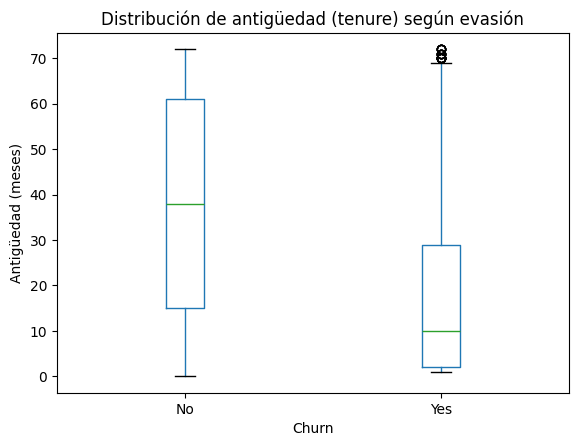

In [49]:
datos_telecom_norm.boxplot(column='tenure', by='Churn', grid=False)
plt.title('Distribución de antigüedad (tenure) según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Antigüedad (meses)')
plt.show()

In [50]:
datos_telecom_norm.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


Los clientes que abandonan el servicio tienden a presentar menor antigüedad. Esto sugiere que el churn ocurre con mayor frecuencia en etapas tempranas de la relación con la empresa.

###Distrib. cargos mensuales

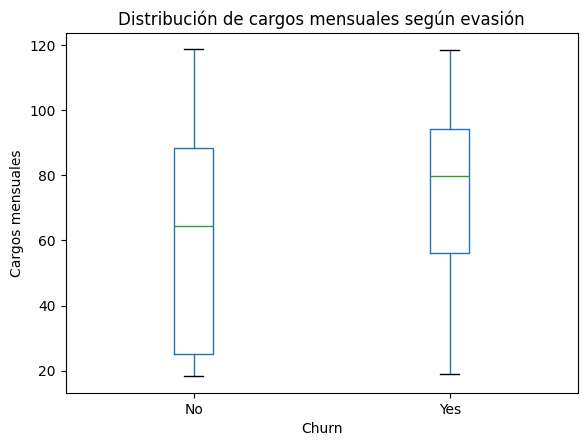

In [51]:
datos_telecom_norm.boxplot(column='Monthly', by='Churn', grid=False)
plt.title('Distribución de cargos mensuales según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cargos mensuales')
plt.show()

In [52]:
datos_telecom_norm.groupby('Churn')['Monthly'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


Los clientes que abandonan el servicio presentan, en promedio, cargos mensuales más elevados. Esto sugiere que el costo del servicio puede influir en la decisión de abandono.

###Distrib. total gastado

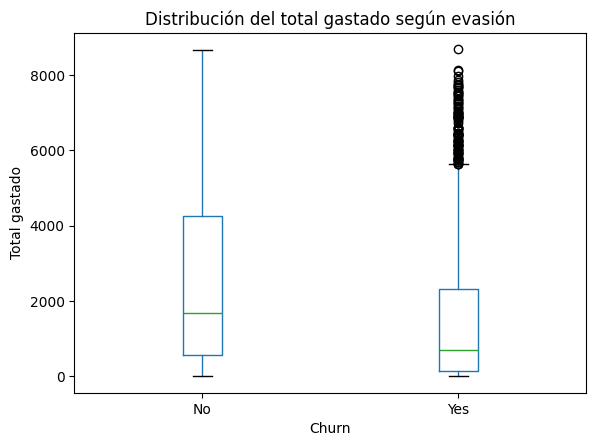

In [53]:
datos_telecom_norm.boxplot(column='Total', by='Churn', grid=False)
plt.title('Distribución del total gastado según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()

In [54]:
datos_telecom_norm.groupby('Churn')['Total'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


El total gastado suele estar asociado a la antigüedad: clientes con menor tenure tienden a acumular menor gasto total y concentran mayor evasión.

Observaciones

tiempo_contrato: los clientes que cancelan suelen tener un tiempo de contrato mucho más corto.

valor_mensual: los clientes con facturas mensuales más altas son más propensos a cancelar.

total_cobrado: los clientes no han acumulado mucha facturación histórica antes de irse.

cuentas_diarias: los clientes con facturas mensuales más altas son más propensos a cancelar.

In [55]:
import seaborn as sns

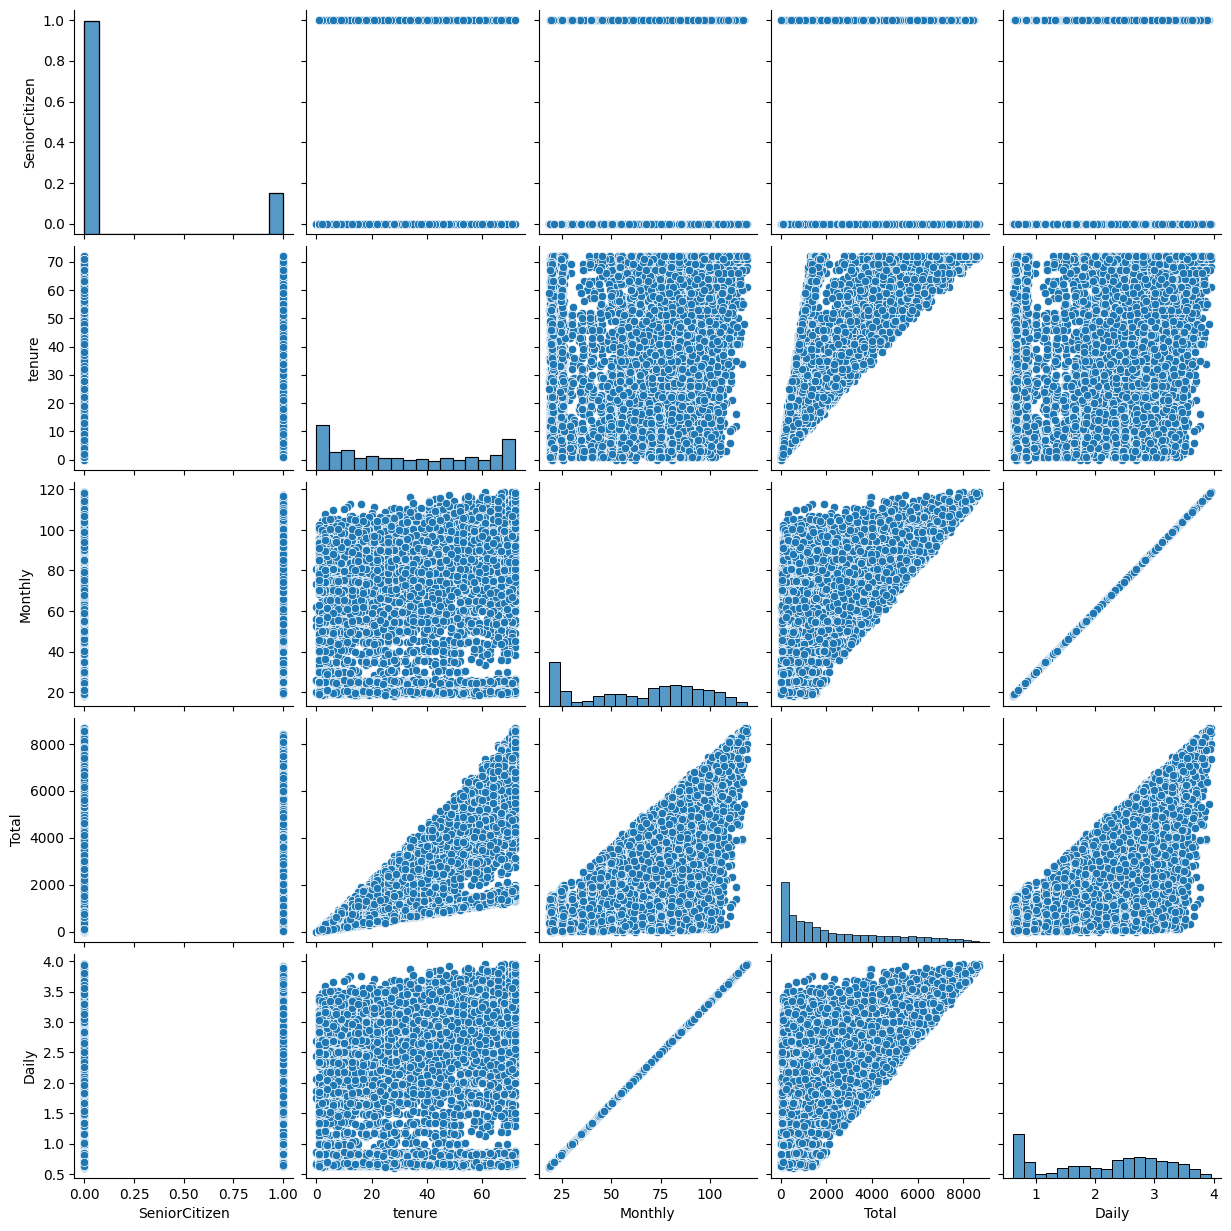

In [56]:
sns.pairplot(datos_telecom_norm)

In [57]:
datos_telecom_norm.columns


Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total', 'Daily'],
      dtype='object')

In [58]:
datos_telecom_norm.sample(3)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Daily
3274,4678-DVQEO,Yes,Female,0,No,No,1,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,52.20,52.20,1.740
6944,9847-HNVGP,No,Male,0,No,No,17,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.95,310.60,0.665
4465,6296-DDOOR,No,Female,0,No,No,19,Yes,No,DSL,No,Yes,No,No,Yes,No,One year,No,Electronic check,58.20,1045.25,1.940


In [59]:
# Correlación
corr = datos_telecom_norm[['SeniorCitizen','Total']].corr()
corr

,SeniorCitizen,Total
SeniorCitizen,1.000000,0.103006
Total,0.103006,1.000000


#📄Informe final

##**INFORME FINAL: ANÁLISIS DE EVASIÓN  DE CLIENTES**
**PROYECTO: TELECOM X**





________________________________________
##**Introducción y alcance**

________________________________________


La empresa Telecom X está enfrentando un alto nivel de evasión de clientes.  Telecom X nos brindó una base de datos guardada en un archivo tipo .JSON para buscar, tratar y realizar un análisis exploratorio de los datos.

El objeto de este análisis e informe es encontrar los factores que influyen en la decisión del abandono del cliente y proponer estrategias basadas en evidencia.




________________________________________
##**Limpieza y Tratamiento de Datos**
________________________________________
•  Se realizó la carga de archivo JSON desde API

•	 Se procesó un conjunto de datos inicial de 7,267

•	Dado que el archivo JSON poseía información anidada, se realizó la normalización para acceder a todas las columnas

•	Se realizó una revisión inicial de los datos, que incorporaba mirar el DataFrame, conocer sus columnas y el tipo de dato que almacenaban, revisar los datos únicos, duplicados, nulos y vacíos.

•	Se realizó una modificación de los tipos de datos donde correspondían, y una nueva limpieza de datos para eliminar todo dato que no sirviera al análisis.

•	Se incorporó una columna para costo diario

•	Se modificaron los nombres de las columnas para dar claridad a la interpretación de los datos








________________________________________
##**Análisis Exploratorio de Datos**
________________________________________
Se realizó una exploración inicial con el método **.describe()**, para valores numéricos con el objeto de tener un acercamiento inicial.

**Análisis General del Dataset**: Se observa un desequilibrio en el abandono de servicio con una Tasa de Retención del 73.5% frente a una Tasa de Abandono del 26.5%.


###**Factores de Abandono (Análisis Categórico)**

•	Genero: En las cancelaciones, NO hay tendencia hacia algún género. El género NO está afectando directamente la cancelación del servicio

•	Permanencia:  Al revisar por tiempo de permanencia, se observa claramente que se concentran las evasiones en aquellos clientes que tienen pocos meses con el servicio

•	Sensibilidad Contractual: Se nota una posible correlación directa entre la modalidad de contrato y la fuga. Los usuarios con contratos "Month-to-month" representan el segmento de mayor riesgo, mientras que los contratos anuales muestran niveles de fidelidad superiores al 90%.  Por lo tanto, podemos decir que, mientras menor el plazo del tipo de contrato, más alta la probabilidad de evasión

•	Desempeño del Servicio: Los usuarios de Fibra Óptica, a pesar de representar el segmento de mayor facturación, muestran tasas de cancelación superiores a los usuarios de DSL, indicando una posible discrepancia entre precio y calidad percibida.

•	Método de Pago: El método de pago "Electronic Check" presenta una tasa de abandono más alta en comparación con métodos automatizados (tarjetas de crédito o transferencias bancarias).


###**Comportamiento Financiero y Temporal (Análisis Numérico)**

•	Permanencia: Los clientes que abandonan el servicio tienden a presentar menor antigüedad. El ‘churn’ ocurre con mayor frecuencia en etapas tempranas de la relación con la empresa.

•	Relación precio-abandono:  Los clientes que abandonan el servicio presentan, en promedio, cargos mensuales más elevados. Esto sugiere que el costo del servicio puede influir en la decisión de abandono.

•	Total gastado:  Al revisar por Total gastado, se observa que la cancelación se concentra en aquellos que tienen un gasto total de 700 o menos (aprox. 50% de las cancelaciones se encuentran en esta observación)



________________________________________
##**Conclusiones e Insights**
________________________________________
•	El abandono de clientes se concentra principalmente en los primeros meses de permanencia.

•	La tasa de evasión general es del 26.6%, lo cual es un porcentaje bastante crítico.

•	La antigüedad del cliente (tenure) mantiene una relación inversa con la evasión. Los clientes que abandonan el servicio tienden a concentrarse en los primeros meses, mientras que aquellos con mayor permanencia presentan una probabilidad significativamente menor de churn

•	Las cancelaciones se concentran en el servicio de Internet por fibra óptica, en aquellos contratos que son mensuales. Puede ser que los clientes prueban el servicio de Internet por 1 mes y posteriormente cancelan el servicio.

•	Los medios de pago no automáticos están asociados a una mayor probabilidad de evasión.

•	El churn no se distribuye de manera uniforme, sino que se concentra en perfiles específicos: clientes recientes, con contratos mensuales y mayores cargos.

•	Los clientes que no usan los servicios de seguridad_online, backup_online y protección_dispositivo, presentan un alto registro de cancelaciones

•	Desde el punto de vista económico, los clientes que cancelan suelen registrar cargos mensuales y diarios más elevados, lo que indica que el costo del servicio puede influir en la decisión de abandono. Este patrón se observa tanto en los análisis gráficos como en el análisis de correlación



________________________________________
##**Recomendaciones**
________________________________________

1)  A los clientes con contratos mensuales, tratar de incentivarlos para que cambien de contrato mensual hacia contratos de mayor duración mediante incentivos tempranos.

2)  Mejorar la percepción del servicio de fibra óptica a través de mejoras técnicas o campañas de satisfacción.

3)  Promover más los métodos de pago automáticos.  Incentivar el cambio de usuarios de "Electronic Check" hacia débitos automáticos,

4)  Hacer un estudio o una evaluación para tratar de rebajar más las tarifas.

5)  Implementar estrategias de retención enfocadas en clientes con baja antigüedad, haciendo énfasis a los primeros meses de relación con la empresa.
6)  Mejorar condiciones comerciales para nuevos clientes que opten por servicios anuales o bianuales, y así asegurar su permanencia.
7)  Desarrollar un modelo predictivo del parámetro ‘churn’.

